# Importar librerías

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
)

# Cargar recursos

In [2]:
# Ruta al directorio donde se encuentran los resultados de la experimentación
OUTPUT_FOLDER = Path("../../outputs/runs/nbaiot_autoencoder_per_device_stage_3/devices")

In [3]:
# Rutas a los archivos de predicciones de cada modelo LOF por dispositivo
DEVICE_1_OUPUT_PATH = OUTPUT_FOLDER / "device_1" / "test_predictions.parquet"
DEVICE_2_OUPUT_PATH = OUTPUT_FOLDER / "device_2" / "test_predictions.parquet"
DEVICE_3_OUPUT_PATH = OUTPUT_FOLDER / "device_3" / "test_predictions.parquet"
DEVICE_4_OUPUT_PATH = OUTPUT_FOLDER / "device_4" / "test_predictions.parquet"
DEVICE_5_OUPUT_PATH = OUTPUT_FOLDER / "device_5" / "test_predictions.parquet"
DEVICE_6_OUPUT_PATH = OUTPUT_FOLDER / "device_6" / "test_predictions.parquet"
DEVICE_7_OUPUT_PATH = OUTPUT_FOLDER / "device_7" / "test_predictions.parquet"
DEVICE_8_OUPUT_PATH = OUTPUT_FOLDER / "device_8" / "test_predictions.parquet"
DEVICE_9_OUPUT_PATH = OUTPUT_FOLDER / "device_9" / "test_predictions.parquet"

In [4]:
# Cargar los resultados en un dataframe de pandas
results_df = pd.concat(
    [
        pd.read_parquet(DEVICE_1_OUPUT_PATH).assign(device=1),
        pd.read_parquet(DEVICE_2_OUPUT_PATH).assign(device=2),
        pd.read_parquet(DEVICE_3_OUPUT_PATH).assign(device=3),
        pd.read_parquet(DEVICE_4_OUPUT_PATH).assign(device=4),
        pd.read_parquet(DEVICE_5_OUPUT_PATH).assign(device=5),
        pd.read_parquet(DEVICE_6_OUPUT_PATH).assign(device=6),
        pd.read_parquet(DEVICE_7_OUPUT_PATH).assign(device=7),
        pd.read_parquet(DEVICE_8_OUPUT_PATH).assign(device=8),
        pd.read_parquet(DEVICE_9_OUPUT_PATH).assign(device=9)
    ],
    ignore_index=True
)

# Analizar resultados

## 1. Rendimiento global sobre el dataset de test completo

En este apartado se evalúa el rendimiento global de la estrategia basada en un autoencoder específico por dispositivo IoT sobre el conjunto de test completo, formado por las particiones de tráfico benigno y tráfico malicioso de los nueve dispositivos considerados.

La evaluación se realiza utilizando los modelos optimizados en el stage 2 y los thresholds seleccionados mediante el percentil 99 del error de reconstrucción sobre la validación benigna de cada dispositivo. Por tanto, el conjunto de test no interviene ni en el entrenamiento ni en la selección de thresholds.

Para evitar que el fuerte desbalanceo del conjunto de test condicione la interpretación inicial, el análisis se centra principalmente en las métricas menos dependientes de la distribución de clases: recall, FPR, balanced accuracy y MCC.

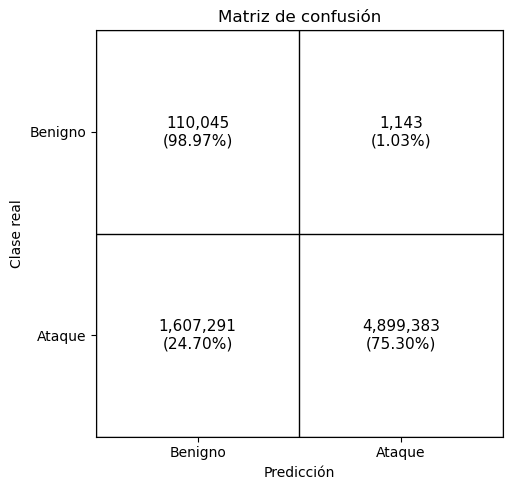

In [5]:
# Calcular la matriz de confusión y los porcentajes normalizados por fila
cm = confusion_matrix(results_df["y_true"], results_df["y_pred"])

cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

cm_labels = np.empty_like(cm, dtype=object)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        cm_labels[i, j] = f"{cm[i, j]:,}\n({cm_percent[i, j]:.2f}%)"


fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(np.ones_like(cm), cmap="gray", vmin=0, vmax=1)
for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            cm_labels[i, j],
            ha="center",
            va="center",
            fontsize=11,
        )

# Dibujar líneas de la cuadrícula
ax.set_xticks(np.arange(-0.5, 2, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 2, 1), minor=True)
ax.grid(which="minor", color="black", linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["Benigno", "Ataque"])
ax.set_yticklabels(["Benigno", "Ataque"])

ax.set_xlabel("Predicción")
ax.set_ylabel("Clase real")
ax.set_title("Matriz de confusión")

plt.tight_layout()
plt.show()

In [6]:
# Tabal de métricas
tn, fp, fn, tp = cm.ravel()
y_true = results_df["y_true"].to_numpy()
y_pred = results_df["y_pred"].to_numpy()
metrics = pd.DataFrame(
    {
        "Métrica": [
            "Recall (TPR)",
            "False Positive Rate (FPR)",
            "Balanced Accuracy",
            "Matthews Correlation Coefficient (MCC)",
            "Precision",
            "F1-score",
            "Accuracy",
            "Specificity (TNR)",
            "False Negative Rate (FNR)",
        ],
        "Valor": [
            recall_score(y_true, y_pred),
            fp / (fp + tn),
            balanced_accuracy_score(y_true, y_pred),
            matthews_corrcoef(y_true, y_pred),
            precision_score(y_true, y_pred),
            f1_score(y_true, y_pred),
            accuracy_score(y_true, y_pred),
            tn / (tn + fp),
            fn / (fn + tp),
        ],
    }
)
metrics["Valor"] = metrics["Valor"].round(4)

display(metrics)

,Métrica,Valor
0,Recall (TPR),0.7530
1,False Positive Rate (FPR),0.0103
2,Balanced Accuracy,0.8713
3,Matthews Correlation Coefficient (MCC),0.2178
4,Precision,0.9998
5,F1-score,0.8590
6,Accuracy,0.7570
7,Specificity (TNR),0.9897
8,False Negative Rate (FNR),0.2470


Los resultados muestran que el autoencoder específico por dispositivo alcanza un **recall global de 0.753**, detectando aproximadamente tres de cada cuatro muestras maliciosas. Al mismo tiempo, mantiene una **FPR de 0.0103**, por lo que solo el 1.03 % del tráfico benigno es clasificado erróneamente como ataque.

La **balanced accuracy de 0.871** resume este comportamiento asimétrico: el modelo conserva una especificidad muy elevada, pero pierde una parte relevante del tráfico malicioso. El **MCC de 0.218** confirma que, aunque existe capacidad discriminativa, el rendimiento global queda limitado por el número de falsos negativos.

En cambio, métricas como precisión, F1-score y accuracy deben interpretarse con cautela en este apartado, ya que el conjunto de test está fuertemente desbalanceado hacia la clase de ataque. Por este motivo, el análisis posterior profundiza en el comportamiento por dispositivo, por tipo de ataque y bajo distribuciones de tráfico más representativas de un entorno real.

## 2. Rendimiento por dispositivo

Tras analizar el comportamiento global de la estrategia, resulta de interés estudiar cómo varía el rendimiento entre los distintos dispositivos IoT. Aunque todos los modelos comparten la misma arquitectura y han sido optimizados siguiendo el mismo protocolo experimental, cada uno de ellos se entrena exclusivamente con el tráfico benigno del dispositivo correspondiente, por lo que cabe esperar diferencias en su capacidad de generalización.

En este apartado se presenta el rendimiento obtenido para cada uno de los nueve dispositivos. El análisis se centra principalmente en el recall, ya que constituye la métrica más representativa para evaluar la capacidad de detección de ataques y permite identificar de forma inmediata aquellos dispositivos en los que el modelo presenta un comportamiento significativamente diferente al resto.

In [7]:
device_metrics = []

for device in sorted(results_df["device"].unique()):

    device_df = results_df[results_df["device"] == device]

    y_true = device_df["y_true"]
    y_pred = device_df["y_pred"]

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    device_metrics.append(
        {
            "Device": device,
            "Recall": recall_score(y_true, y_pred),
            "FPR": fp / (fp + tn),
            "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
            "MCC": matthews_corrcoef(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred),
            "F1-score": f1_score(y_true, y_pred),
            "Accuracy": accuracy_score(y_true, y_pred),
            "Specificity": tn / (tn + fp),
            "FNR": fn / (fn + tp),
        }
    )

device_metrics_df = pd.DataFrame(device_metrics)

display(device_metrics_df)

,Device,Recall,FPR,Balanced Accuracy,MCC,Precision,F1-score,Accuracy,Specificity,FNR
0,1,1.000000,0.010494,0.994753,0.994686,0.999893,0.999946,0.999894,0.989506,0.000000
1,2,0.757366,0.012200,0.872583,0.097516,0.999949,0.861914,0.758099,0.987800,0.242634
2,3,0.351188,0.008696,0.671246,0.110694,0.999388,0.519739,0.366628,0.991304,0.648812
3,4,0.785247,0.010728,0.887259,0.338911,0.999482,0.879506,0.792707,0.989272,0.214753
4,5,0.727996,0.010297,0.858850,0.199615,0.999771,0.842508,0.732175,0.989703,0.272004
5,6,0.737411,0.009339,0.864036,0.257576,0.999662,0.848740,0.743993,0.990661,0.262589
6,7,0.355246,0.011122,0.672062,0.126047,0.998990,0.524114,0.375062,0.988878,0.644754
7,8,0.764145,0.009660,0.877242,0.185444,0.999856,0.866252,0.766697,0.990340,0.235855
8,9,0.758304,0.011521,0.873392,0.118434,0.999929,0.862514,0.759381,0.988479,0.241696


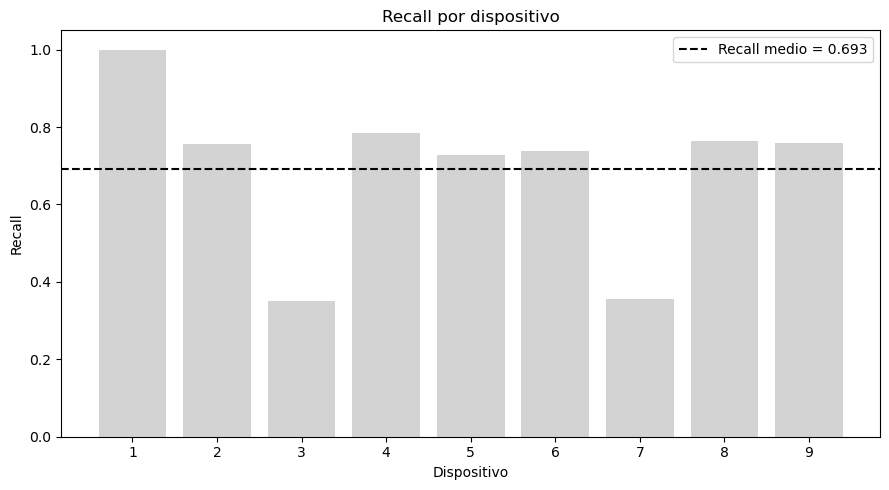

In [8]:
plt.figure(figsize=(9, 5))

plt.bar(
    device_metrics_df["Device"].astype(str),
    device_metrics_df["Recall"],
    color="lightgray"
)

plt.axhline(
    device_metrics_df["Recall"].mean(),
    linestyle="--",
    linewidth=1.5,
    label=f"Recall medio = {device_metrics_df['Recall'].mean():.3f}",
    color="black"
)

plt.ylim(0, 1.05)

plt.xlabel("Dispositivo")
plt.ylabel("Recall")
plt.title("Recall por dispositivo")
plt.legend()

plt.tight_layout()
plt.show()

Los resultados muestran que el rendimiento del autoencoder no es homogéneo entre los distintos dispositivos. Mientras que el **dispositivo 1** alcanza un recall del **100 %**, la mayoría de dispositivos presentan valores comprendidos entre **0.73 y 0.79**, lo que indica un comportamiento relativamente consistente. Sin embargo, los **dispositivos 3 y 7** constituyen una excepción clara, con valores próximos a **0.35**, muy inferiores al resto.

Esta diferencia también se refleja en el resto de métricas. En particular, los dispositivos 3 y 7 presentan las menores balanced accuracy y MCC, consecuencia directa del elevado número de falsos negativos, mientras que la FPR permanece próxima al 1 % en todos los casos. Esto indica que las diferencias observadas entre dispositivos no se deben a un aumento de falsas alarmas, sino exclusivamente a una menor capacidad para detectar determinadas muestras de ataque.

Estos resultados sugieren que la dificultad de la detección no depende únicamente del dispositivo IoT considerado. De hecho, durante el análisis exploratorio se observó que cada dispositivo presenta una composición diferente de muestras benignas y de las distintas familias de ataque, lo que podría influir en el rendimiento obtenido. No obstante, a partir de este análisis no es posible determinar si las diferencias observadas se deben al propio dispositivo o a la naturaleza de los ataques presentes en él. Por este motivo, en el siguiente apartado se analiza el rendimiento desagregado por familia y tipo de ataque con el objetivo de identificar el origen de esta variabilidad.

## 3. Rendimiento por familia de ataque

In [9]:
attack_df = results_df[results_df["y_true"] == 1].copy()

### 3.1 Comparativa global por familia de ataque

Una vez analizada la variabilidad existente entre dispositivos, el siguiente paso consiste en estudiar cómo influye la familia de ataque en el rendimiento del detector. Este análisis permite determinar si las diferencias observadas anteriormente están asociadas al comportamiento particular de determinados dispositivos o, por el contrario, a la naturaleza de los ataques evaluados.

Para ello, se calcula el recall de forma agregada para cada una de las 2 familias de *botnets* presentes en N-BaIoT: **Mirai** y **Gafgyt**. Esta comparación ofrece una primera visión sobre la capacidad del modelo para detectar ambas familias antes de profundizar en el análisis individual de cada tipo de ataque.

In [10]:
family_metrics_df = (
    attack_df
    .groupby("attack_family")
    .agg(
        n_samples=("y_true", "size"),
        true_positives=("y_pred", "sum"),
    )
    .reset_index()
)

family_metrics_df["false_negatives"] = (
    family_metrics_df["n_samples"] - family_metrics_df["true_positives"]
)

family_metrics_df["Recall"] = (
    family_metrics_df["true_positives"] / family_metrics_df["n_samples"]
)

family_metrics_df["FNR"] = (
    family_metrics_df["false_negatives"] / family_metrics_df["n_samples"]
)

family_metrics_df = family_metrics_df[
    [
        "attack_family",
        "n_samples",
        "true_positives",
        "false_negatives",
        "Recall",
        "FNR",
    ]
].sort_values("Recall", ascending=False)

display(family_metrics_df)

,attack_family,n_samples,true_positives,false_negatives,Recall,FNR
1,mirai,3668402,3668166,236,0.999936,0.000064
0,gafgyt,2838272,1231217,1607055,0.433791,0.566209


Los resultados muestran una diferencia muy marcada entre ambas familias de ataque. Mientras que el modelo detecta prácticamente la totalidad de las muestras pertenecientes a **Mirai**, alcanzando un recall de **0.9999**, el rendimiento sobre **Gafgyt** desciende hasta **0.4338**, concentrándose en esta familia la práctica totalidad de los falsos negativos observados durante la evaluación.

Esta diferencia indica que la capacidad de detección del autoencoder no depende únicamente del hecho de tratarse de tráfico malicioso, sino también del comportamiento característico de cada familia de botnets. No obstante, este análisis agregado no permite determinar si la pérdida de rendimiento afecta por igual a todos los ataques de Gafgyt o si se concentra en alguno de ellos. Por este motivo, resulta necesario desagregar el análisis al nivel de tipo de ataque.

### 3.2 Comparativa global por tipo de ataque

Con el objetivo de identificar el origen de las diferencias observadas entre las familias de ataque, en este apartado se analiza el rendimiento del detector para cada uno de los diez tipos de ataque incluidos en N-BaIoT.

Este análisis permite determinar qué ataques resultan más difíciles de detectar y comprobar si la pérdida de rendimiento observada sobre la familia Gafgyt se distribuye de forma homogénea entre todos sus ataques o se concentra únicamente en algunos de ellos.

In [11]:
type_metrics_df = (
    attack_df
    .groupby(["attack_family", "attack_type"])
    .agg(
        n_samples=("y_true", "size"),
        true_positives=("y_pred", "sum"),
    )
    .reset_index()
)

type_metrics_df["false_negatives"] = (
    type_metrics_df["n_samples"] - type_metrics_df["true_positives"]
)

type_metrics_df["Recall"] = (
    type_metrics_df["true_positives"] / type_metrics_df["n_samples"]
)

type_metrics_df["FNR"] = (
    type_metrics_df["false_negatives"] / type_metrics_df["n_samples"]
)

type_metrics_df["attack_label"] = (
    type_metrics_df["attack_family"].astype(str)
    + " - "
    + type_metrics_df["attack_type"].astype(str)
)

type_metrics_df = type_metrics_df[
    [
        "attack_family",
        "attack_type",
        "attack_label",
        "n_samples",
        "true_positives",
        "false_negatives",
        "Recall",
        "FNR",
    ]
].sort_values("Recall", ascending=True)

display(type_metrics_df)

,attack_family,attack_type,attack_label,n_samples,true_positives,false_negatives,Recall,FNR
3,gafgyt,tcp,gafgyt - tcp,859850,92750,767100,0.107868,0.892132
4,gafgyt,udp,gafgyt - udp,946366,106531,839835,0.112568,0.887432
6,mirai,scan,mirai - scan,537979,537818,161,0.999701,0.000299
2,gafgyt,scan,gafgyt - scan,255111,255052,59,0.999769,0.000231
1,gafgyt,junk,gafgyt - junk,261789,261751,38,0.999855,0.000145
0,gafgyt,combo,gafgyt - combo,515156,515133,23,0.999955,0.000045
8,mirai,udp,mirai - udp,1229999,1229963,36,0.999971,0.000029
7,mirai,syn,mirai - syn,733299,733278,21,0.999971,0.000029
5,mirai,ack,mirai - ack,643821,643808,13,0.999980,0.000020
9,mirai,udpplain,mirai - udpplain,523304,523299,5,0.999990,0.000010


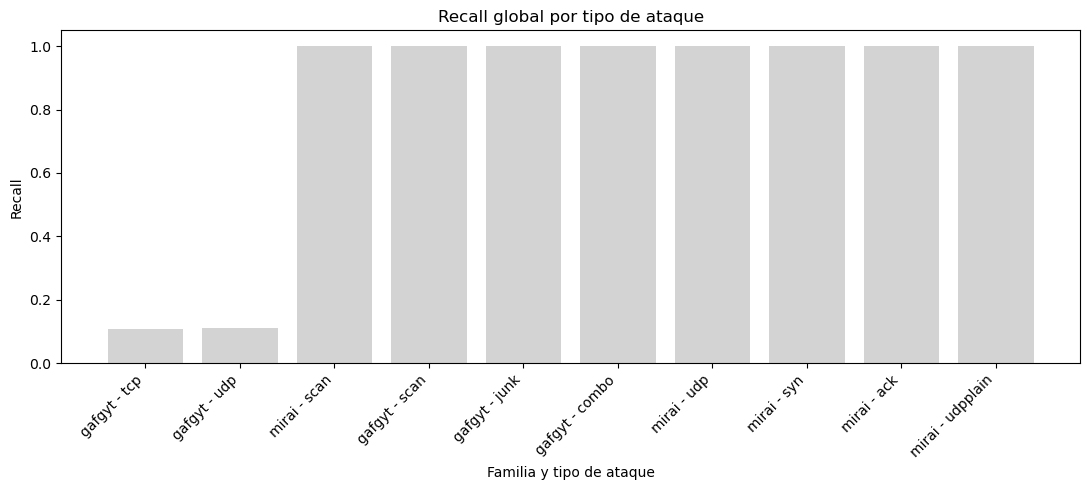

In [12]:
plt.figure(figsize=(11, 5))

type_metrics_df = type_metrics_df.sort_values("Recall", ascending=True)
plt.bar(
    type_metrics_df["attack_label"],
    type_metrics_df["Recall"],
    color="lightgray"
)

plt.ylim(0, 1.05)

plt.xlabel("Familia y tipo de ataque")
plt.ylabel("Recall")
plt.title("Recall global por tipo de ataque")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

El análisis por tipo de ataque revela que el comportamiento del autoencoder es altamente consistente para la mayoría de escenarios evaluados. En concreto, **8 de los 10 ataques** presentan un recall prácticamente perfecto, cercano al **100 %**, lo que demuestra que el modelo es capaz de detectar de forma muy fiable la mayor parte de los comportamientos maliciosos presentes en el dataset.

Sin embargo, existen 2 excepciones claramente diferenciadas: **Gafgyt TCP** y **Gafgyt UDP**, cuyos recalls descienden hasta **0.1079** y **0.1126**, respectivamente. Estos 2 ataques concentran prácticamente la totalidad de los falsos negativos observados durante la evaluación y explican, en consecuencia, la pérdida de rendimiento obtenida previamente para la familia Gafgyt.

Estos resultados sugieren que el comportamiento observado en el apartado anterior no es representativo de toda la familia Gafgyt, sino que parece estar condicionado por un subconjunto muy concreto de ataques. Asimismo, también plantean la hipótesis de que las diferencias de rendimiento observadas entre dispositivos podrían estar relacionadas con la distribución de estos tipos de ataque en cada uno de ellos, cuestión que se analiza en el siguiente subapartado.

### 3.3 Relación con el rendimiento por dispositivo

Los apartados anteriores han puesto de manifiesto una elevada variabilidad en el rendimiento entre dispositivos, así como la especial dificultad que presentan los ataques **Gafgyt TCP** y **Gafgyt UDP**. En este subapartado se analizan de forma específica los 3 dispositivos con un comportamiento más representativo: 

- El **dispositivo 1**, que alcanza un recall del 100 %
- Los **dispositivos 3 y 7**, que presentan los menores valores de recall de toda la experimentación.

El objetivo de este análisis es determinar si las diferencias observadas entre estos dispositivos pueden explicarse por el comportamiento del detector frente a los distintos tipos de ataque o si, por el contrario, responden a otros factores asociados al propio dispositivo.

In [32]:
extreme_devices = [1, 3, 7]

extreme_attack_df = attack_df[
    attack_df["device"].isin(extreme_devices)
].copy()

In [33]:
extreme_type_metrics_df = (
    extreme_attack_df
    .groupby(["device", "attack_family", "attack_type"])
    .agg(
        n_samples=("y_true", "size"),
        true_positives=("y_pred", "sum"),
    )
    .reset_index()
)

extreme_type_metrics_df["false_negatives"] = (
    extreme_type_metrics_df["n_samples"] - extreme_type_metrics_df["true_positives"]
)

extreme_type_metrics_df["Recall"] = (
    extreme_type_metrics_df["true_positives"] / extreme_type_metrics_df["n_samples"]
)

extreme_type_metrics_df["FNR"] = (
    extreme_type_metrics_df["false_negatives"] / extreme_type_metrics_df["n_samples"]
)

extreme_type_metrics_df["attack_label"] = (
    extreme_type_metrics_df["attack_family"].astype(str)
    + " - "
    + extreme_type_metrics_df["attack_type"].astype(str)
)

display(
    extreme_type_metrics_df[
        [
            "device",
            "attack_family",
            "attack_type",
            "n_samples",
            "true_positives",
            "false_negatives",
            "Recall",
            "FNR",
        ]
    ].sort_values(["device", "Recall"])
)

,device,attack_family,attack_type,n_samples,true_positives,false_negatives,Recall,FNR
0,1,gafgyt,combo,59718,59718,0,1.000000,0.000000
1,1,gafgyt,junk,29068,29068,0,1.000000,0.000000
2,1,gafgyt,scan,29849,29849,0,1.000000,0.000000
3,1,gafgyt,tcp,92141,92141,0,1.000000,0.000000
4,1,gafgyt,udp,105874,105874,0,1.000000,0.000000
5,1,mirai,ack,102195,102195,0,1.000000,0.000000
6,1,mirai,scan,107685,107685,0,1.000000,0.000000
7,1,mirai,syn,122573,122573,0,1.000000,0.000000
8,1,mirai,udp,237665,237665,0,1.000000,0.000000
9,1,mirai,udpplain,81982,81982,0,1.000000,0.000000


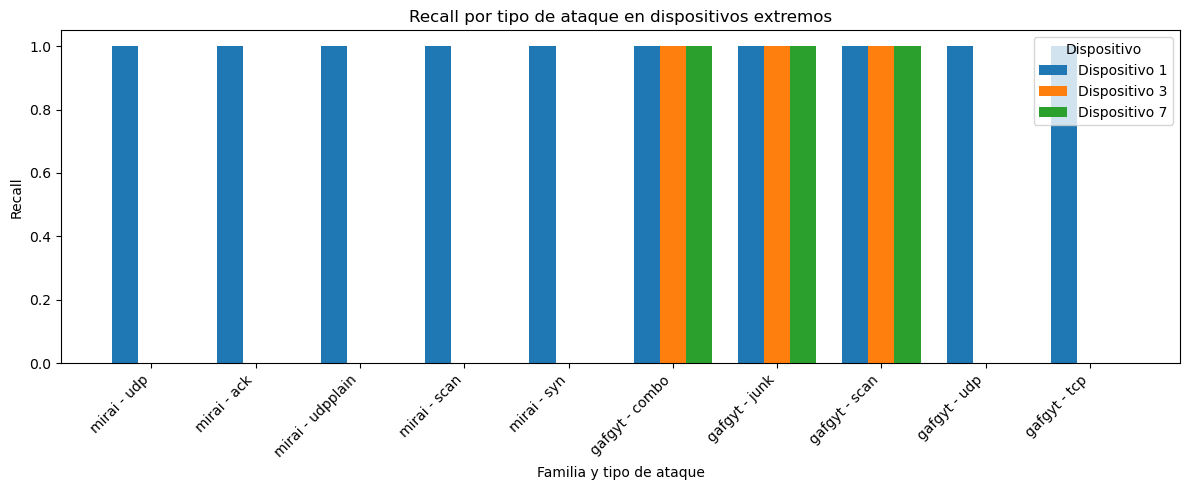

In [34]:
extreme_type_recall_df = (
    extreme_type_metrics_df
    .pivot(
        index="attack_label",
        columns="device",
        values="Recall",
    )
)

# Ordenar los ataques por el Recall medio de los dispositivos donde aparecen
extreme_type_recall_df = extreme_type_recall_df.loc[
    extreme_type_recall_df.mean(axis=1).sort_values(ascending=False).index
]

x = np.arange(len(extreme_type_recall_df.index))
bar_width = 0.25

plt.figure(figsize=(12, 5))

for offset, device in enumerate(extreme_devices):
    values = extreme_type_recall_df[device] if device in extreme_type_recall_df.columns else np.nan

    plt.bar(
        x + (offset - 1) * bar_width,
        values,
        width=bar_width,
        label=f"Dispositivo {device}",
    )

plt.ylim(0, 1.05)

plt.xlabel("Familia y tipo de ataque")
plt.ylabel("Recall")
plt.title("Recall por tipo de ataque en dispositivos extremos")

plt.xticks(
    x,
    extreme_type_recall_df.index,
    rotation=45,
    ha="right",
)

plt.legend(title="Dispositivo")

plt.tight_layout()
plt.show()

Los resultados confirman que las diferencias observadas entre los dispositivos 1, 3 y 7 se deben exclusivamente al comportamiento del detector frente a los ataques **Gafgyt TCP** y **Gafgyt UDP**.

En el **dispositivo 1**, el autoencoder detecta correctamente la totalidad de las muestras pertenecientes a los 10 tipos de ataque, alcanzando un recall del **100 %** en todos ellos. Por el contrario, los **dispositivos 3 y 7** mantienen un comportamiento prácticamente idéntico para 3 de los 5 tipos de ataque de Gafgyt, con recalls cercanos al **100 %**, pero experimentan una pérdida casi total de capacidad de detección sobre **Gafgyt TCP** y **Gafgyt UDP**, cuyos recalls descienden hasta valores próximos a cero.

Este resultado explica directamente las diferencias de rendimiento observadas entre dispositivos en el apartado 2. Aunque los dispositivos 3 y 7 mantienen un comportamiento prácticamente idéntico al del dispositivo 1 para la mayor parte de los ataques, la incapacidad para detectar únicamente estos 2 tipos de ataque reduce de forma significativa su recall global.

En consecuencia, puede concluirse que la elevada variabilidad observada entre dispositivos no responde a un deterioro generalizado del modelo, sino a un comportamiento muy localizado sobre un subconjunto específico de ataques. Esta conclusión refuerza la idea de que los ataques **Gafgyt TCP** y **Gafgyt UDP** constituyen el principal factor limitante del rendimiento de la estrategia basada en autoencoders específicos por dispositivo.

## 4. Análisis de margen de mejora mediante ajuste supervisado del *threshold*

Hasta este punto, la evaluación se ha realizado empleando los thresholds seleccionados durante el stage 2 a partir del percentil 99 del error de reconstrucción sobre el conjunto de validación benigno. Este procedimiento es coherente con un escenario de detección de anomalías completamente no supervisado, donde únicamente se dispone de tráfico normal durante la fase de entrenamiento y validación.

No obstante, en determinados entornos puede resultar factible disponer de un pequeño conjunto de muestras etiquetadas de tráfico malicioso obtenidas durante la puesta en marcha del sistema o a partir de incidentes previamente identificados. En estos casos, resulta de interés analizar cuál sería el margen de mejora alcanzable sin modificar los modelos entrenados, ajustando únicamente el valor del threshold.

Con este objetivo, en este apartado se calcula, para cada dispositivo, el threshold que maximiza el coeficiente de correlación de Matthews (MCC) sobre el conjunto de test. Aunque este procedimiento introduce información supervisada y, por tanto, no constituye un escenario válido de evaluación, permite estimar el potencial de mejora de la estrategia cuando el único parámetro que se modifica es el criterio de decisión final.

In [6]:
CURRENT_THRESHOLDS = {
    1: 0.7588,
    2: 0.5914,
    3: 0.8101,
    4: 0.6234,
    5: 0.2667,
    6: 0.1756,
    7: 1.1105,
    8: 0.3552,
    9: 1.3960,
}

def find_optimal_threshold_by_mcc(
    y_true,
    scores,
    n_candidates=2000,
    min_quantile=0.0,
    max_quantile=1.0,
):
    """
    Calcula un threshold aproximado maximizando MCC sobre una rejilla de cuantiles.
    Se asume que mayor score implica mayor anomalía.
    """

    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores).astype(float)

    quantiles = np.linspace(min_quantile, max_quantile, n_candidates)
    candidate_thresholds = np.quantile(scores, quantiles)
    candidate_thresholds = np.unique(candidate_thresholds)

    best_threshold = None
    best_mcc = -np.inf

    for th in tqdm(candidate_thresholds):
        y_pred = (scores > th).astype(int)
        mcc = matthews_corrcoef(y_true, y_pred)

        if mcc > best_mcc:
            best_mcc = mcc
            best_threshold = th

    return {
        "threshold": best_threshold,
        "mcc": best_mcc,
    }


def compute_binary_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "FPR": fp / (fp + tn),
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
    }

In [7]:
threshold_rows = []

for device in sorted(results_df["device"].unique()):
    device_df = results_df[results_df["device"] == device].copy()

    y_true = device_df["y_true"].astype(int).to_numpy()
    errors = device_df["reconstruction_error"].to_numpy()

    current_th = CURRENT_THRESHOLDS[device]
    optimal_info = find_optimal_threshold_by_mcc(y_true, errors, n_candidates=2000, min_quantile=0.0, max_quantile=0.5)
    optimal_th = optimal_info["threshold"]

    y_pred_current = (errors > current_th).astype(int)
    y_pred_optimal = (errors > optimal_th).astype(int)

    current_metrics = compute_binary_metrics(y_true, y_pred_current)
    optimal_metrics = compute_binary_metrics(y_true, y_pred_optimal)

    threshold_rows.append({
        "device": device,
        "current_threshold": current_th,
        "optimal_threshold": optimal_th,

        "current_recall": current_metrics["Recall"],
        "optimal_recall": optimal_metrics["Recall"],

        "current_fpr": current_metrics["FPR"],
        "optimal_fpr": optimal_metrics["FPR"],

        "current_precision": current_metrics["Precision"],
        "optimal_precision": optimal_metrics["Precision"],

        "current_mcc": current_metrics["MCC"],
        "optimal_mcc": optimal_metrics["MCC"],
    })

threshold_analysis_df = pd.DataFrame(threshold_rows)

display(threshold_analysis_df.round(4))

100%|██████████| 1041/1041 [01:59<00:00,  8.74it/s]


,device,current_threshold,optimal_threshold,current_recall,optimal_recall,current_fpr,optimal_fpr,current_precision,optimal_precision,current_mcc,optimal_mcc
0,1,0.7588,0.6193,1.0000,1.0000,0.0105,0.0119,0.9999,0.9999,0.9947,0.9940
1,2,0.5914,0.1452,0.7574,1.0000,0.0122,0.0553,0.9999,0.9998,0.0975,0.9719
2,3,0.8101,0.2820,0.3512,1.0000,0.0087,0.0266,0.9994,0.9993,0.1107,0.9856
3,4,0.6234,0.2603,0.7852,0.9999,0.0107,0.0307,0.9995,0.9988,0.3389,0.9829
4,5,0.2667,0.0487,0.7280,1.0000,0.0103,0.0774,0.9998,0.9987,0.1996,0.9590
5,6,0.1756,0.1573,0.7374,1.0000,0.0093,0.0105,0.9997,0.9997,0.2576,0.9937
6,7,1.1105,0.3419,0.3552,0.9999,0.0111,0.0344,0.9990,0.9989,0.1260,0.9809
7,8,0.3552,0.1631,0.7641,0.9999,0.0097,0.0309,0.9999,0.9996,0.1854,0.9810
8,9,1.3960,0.3826,0.7583,1.0000,0.0115,0.0371,0.9999,0.9998,0.1184,0.9812


In [8]:
def assign_score_group(row):
    if row["y_true"] == 0:
        return "Benigno"

    if row["attack_family"] == "gafgyt" and row["attack_type"] in ["tcp", "udp"]:
        return "Gafgyt TCP/UDP"

    return "Resto de ataques"


plot_df = results_df.copy()
plot_df["score_group"] = plot_df.apply(assign_score_group, axis=1)


COLOR_GROUPS = [
    ("Benigno", "tab:blue", 0.45),
    ("Gafgyt TCP/UDP", "tab:red", 0.45),
    ("Resto de ataques", "lightcoral", 0.35),
]

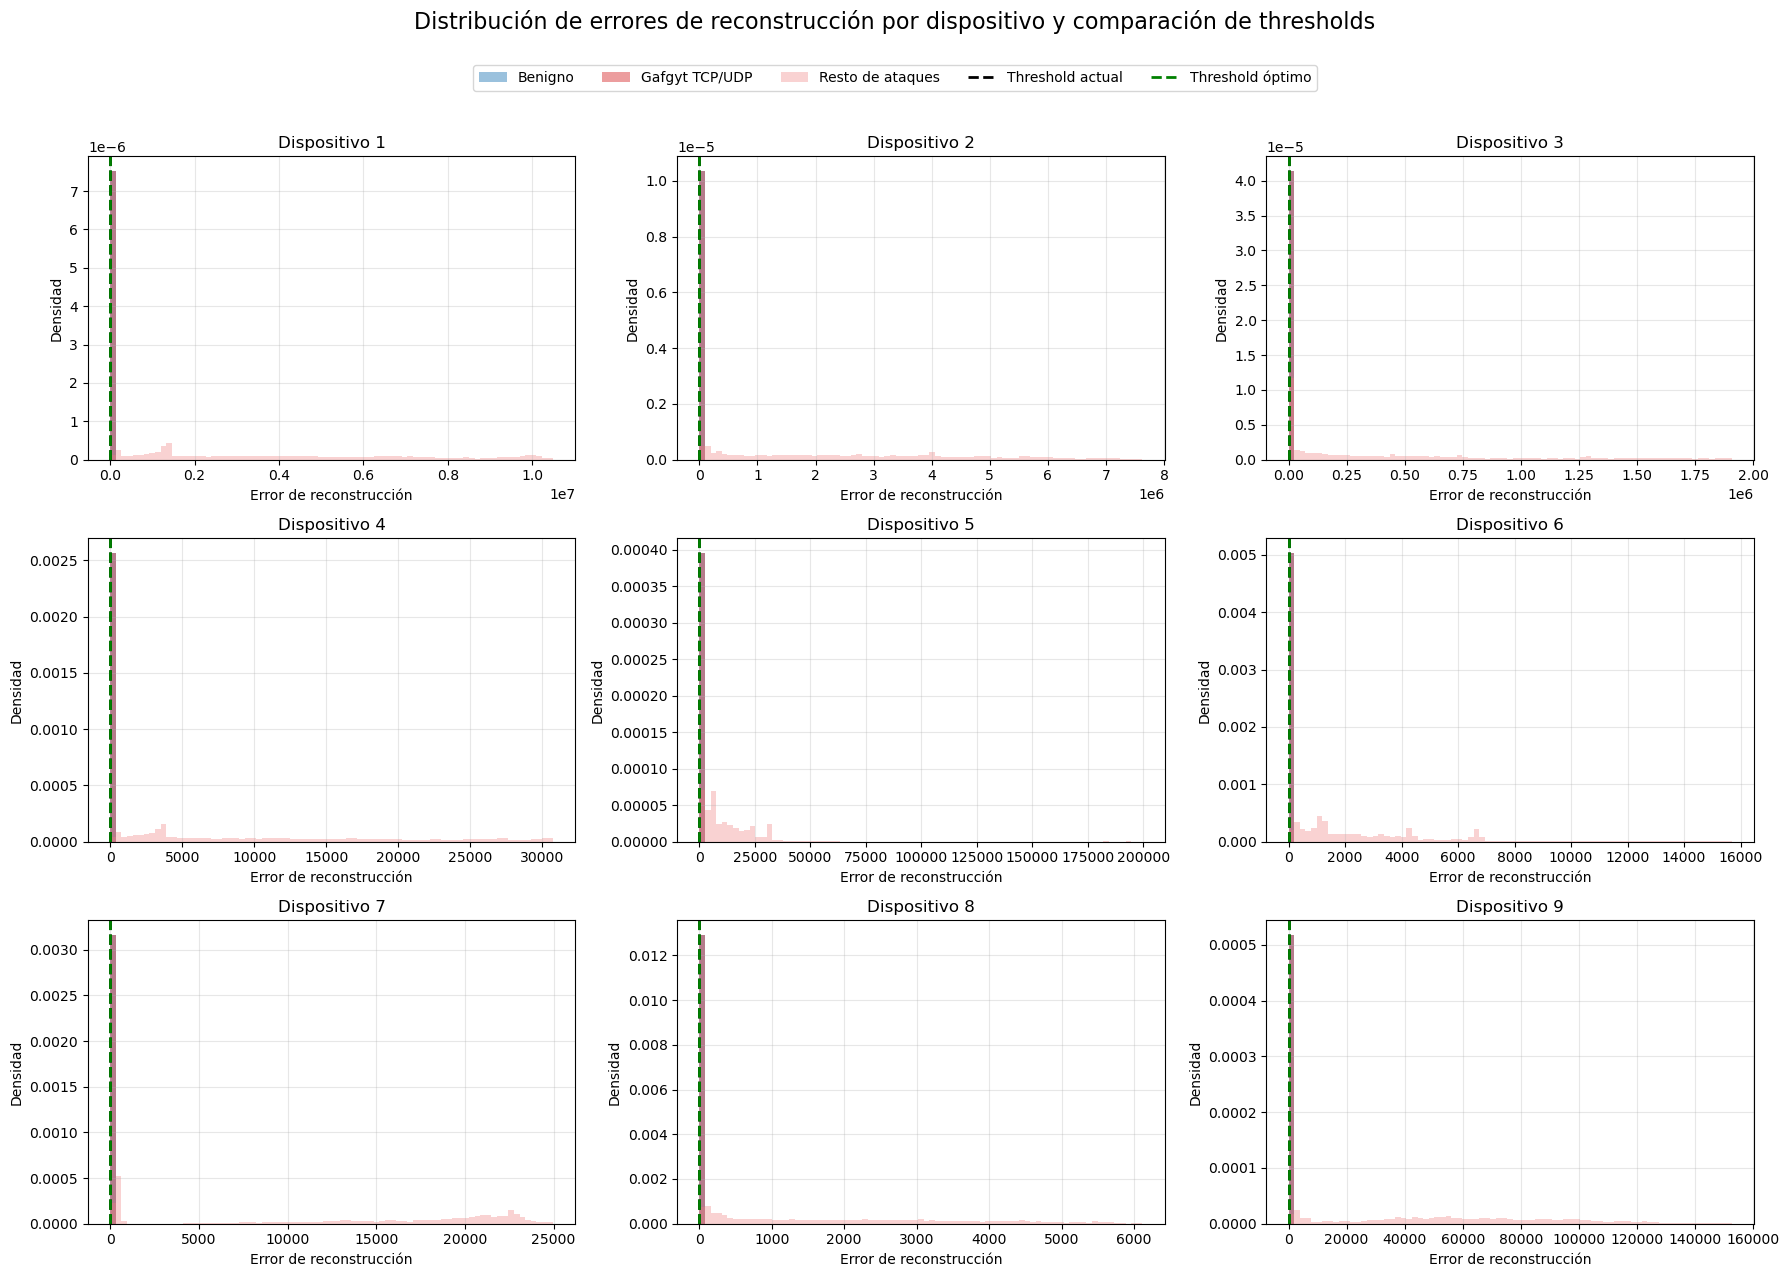

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for ax, device in zip(axes, sorted(plot_df["device"].unique())):
    device_df = plot_df[plot_df["device"] == device]

    current_th = CURRENT_THRESHOLDS[device]
    optimal_th = threshold_analysis_df.loc[
        threshold_analysis_df["device"] == device,
        "optimal_threshold"
    ].iloc[0]

    max_error_for_plot = np.quantile(device_df["reconstruction_error"], 0.995)
    max_error_for_plot = max(max_error_for_plot, current_th, optimal_th)

    bins = np.linspace(0, max_error_for_plot, 80)

    for group_name, color, alpha in COLOR_GROUPS:
        values = device_df.loc[
            device_df["score_group"] == group_name,
            "reconstruction_error"
        ]

        if len(values) == 0:
            continue

        ax.hist(
            values,
            bins=bins,
            density=True,
            alpha=alpha,
            color=color,
            label=group_name,
        )

    ax.axvline(
        current_th,
        color="black",
        linestyle="--",
        linewidth=2,
        label="Threshold actual",
    )

    ax.axvline(
        optimal_th,
        color="green",
        linestyle="--",
        linewidth=2,
        label="Threshold óptimo",
    )

    ax.set_title(f"Dispositivo {device}")
    ax.set_xlabel("Error de reconstrucción")
    ax.set_ylabel("Densidad")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=5,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle(
    "Distribución de errores de reconstrucción por dispositivo y comparación de thresholds",
    fontsize=16,
    y=1.06,
)

fig.tight_layout()
plt.show()

/home/pablo/miniconda3/envs/master-tfm/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


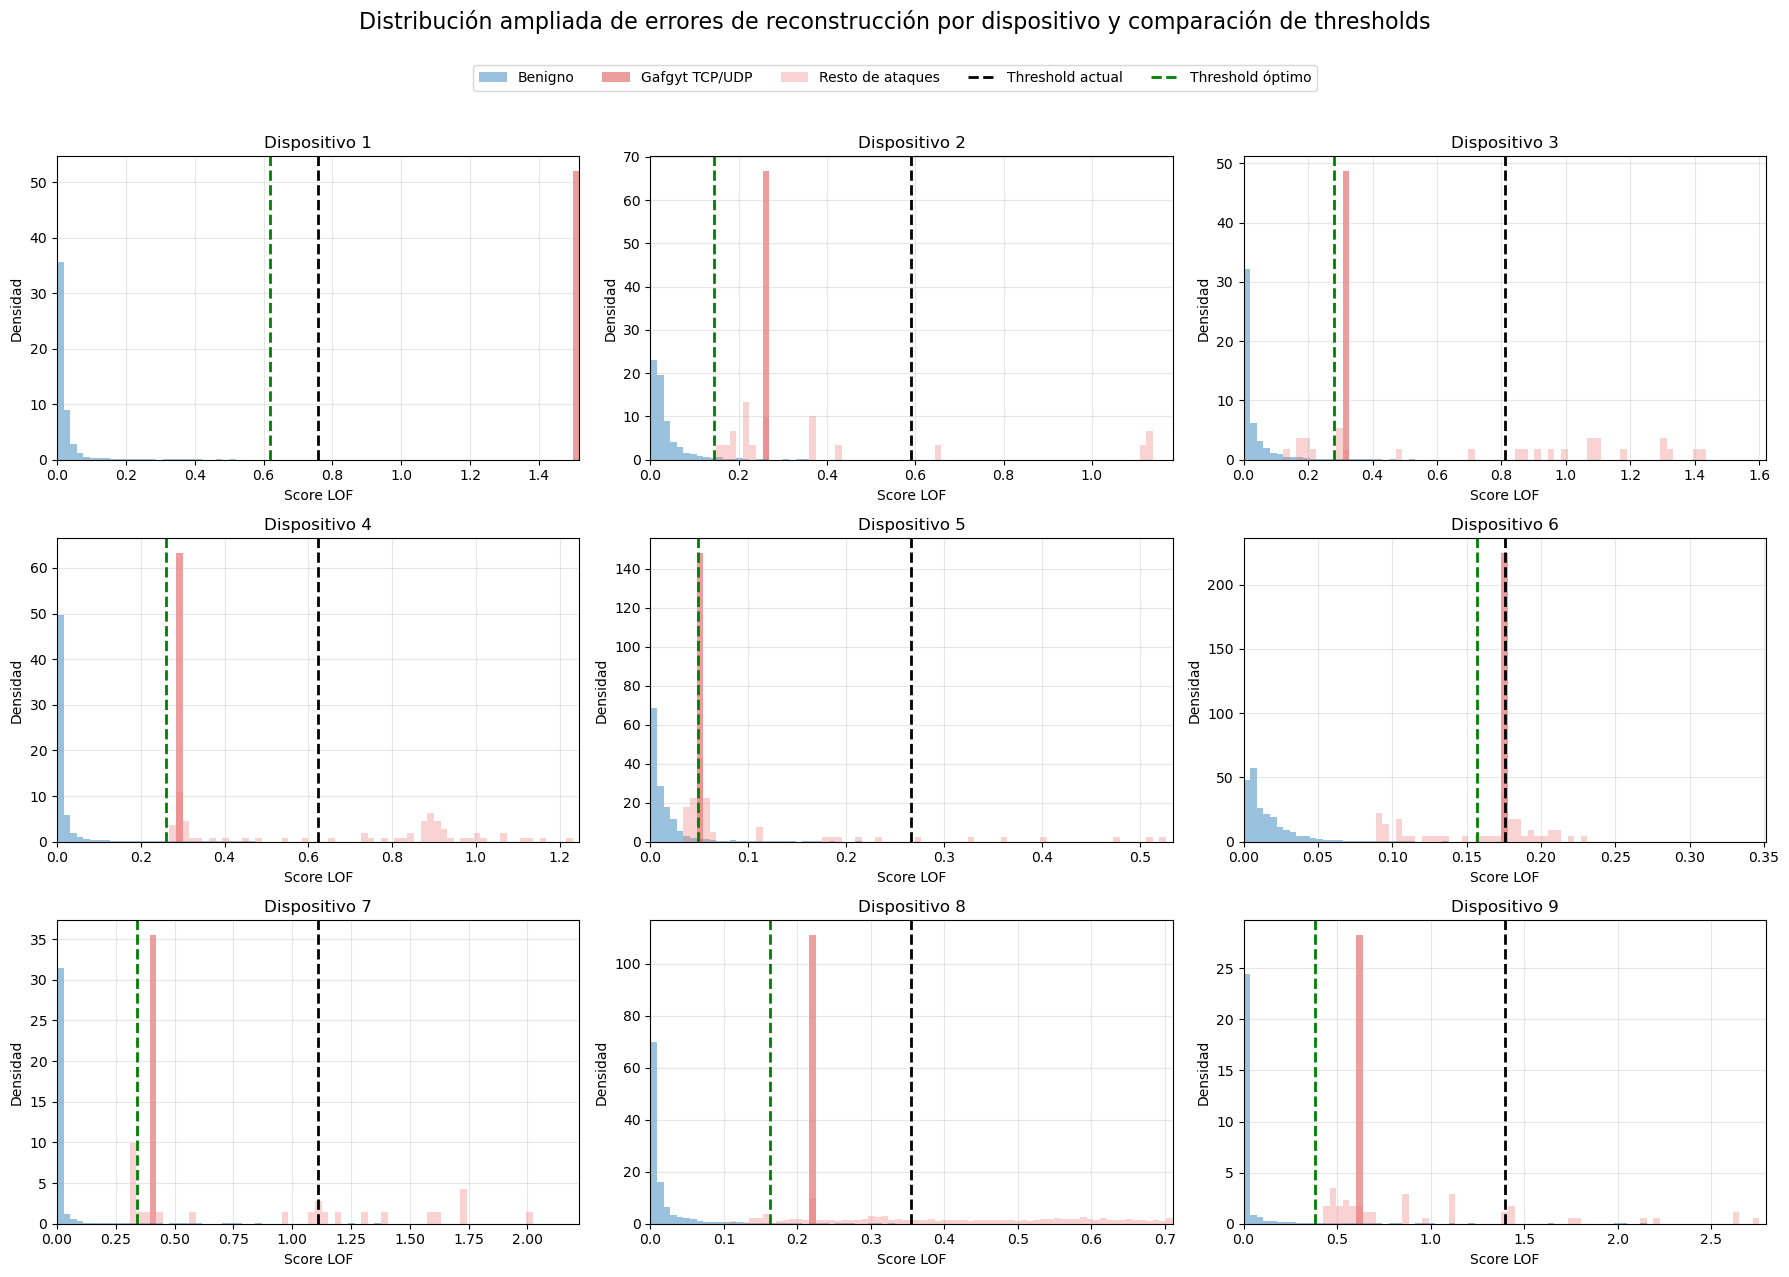

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for ax, device in zip(axes, sorted(plot_df["device"].unique())):
    device_df = plot_df[plot_df["device"] == device]

    current_th = CURRENT_THRESHOLDS[device]
    optimal_th = threshold_analysis_df.loc[
        threshold_analysis_df["device"] == device,
        "optimal_threshold"
    ].iloc[0]

    max_error_for_plot = max(current_th * 2, optimal_th * 2)

    bins = np.linspace(0, max_error_for_plot, 80)

    for group_name, color, alpha in COLOR_GROUPS:
        values = device_df.loc[
            device_df["score_group"] == group_name,
            "reconstruction_error"
        ]

        if len(values) == 0:
            continue

        ax.hist(
            values,
            bins=bins,
            density=True,
            alpha=alpha,
            color=color,
            label=group_name,
        )

        ax.set_xlim(0,max_error_for_plot)

    ax.axvline(
        current_th,
        color="black",
        linestyle="--",
        linewidth=2,
        label="Threshold actual",
    )

    ax.axvline(
        optimal_th,
        color="green",
        linestyle="--",
        linewidth=2,
        label="Threshold óptimo",
    )

    ax.set_title(f"Dispositivo {device}")
    ax.set_xlabel("Score LOF")
    ax.set_ylabel("Densidad")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=5,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle(
    "Distribución ampliada de errores de reconstrucción por dispositivo y comparación de thresholds",
    fontsize=16,
    y=1.06,
)

fig.tight_layout()
plt.show()

Los resultados muestran que existe un margen de mejora muy significativo asociado exclusivamente a la selección del threshold. En todos los dispositivos, el ajuste supervisado del punto de decisión incrementa de forma notable el recall, alcanzando valores prácticamente del **100 %**, mientras que el aumento de la tasa de falsas alarmas permanece relativamente contenido, situándose generalmente entre el **2 % y el 8 %**.

Esta mejora se refleja especialmente en el coeficiente **MCC**, que pasa de valores comprendidos entre **0.10 y 0.34** con los thresholds seleccionados durante el stage 2 a valores próximos o superiores a **0.98** en todos los dispositivos. Este comportamiento indica que el autoencoder es capaz de generar una separación muy clara entre el tráfico benigno y el malicioso, pero que dicha capacidad no se aprovecha completamente mediante un criterio de selección de threshold basado exclusivamente en tráfico benigno.

El análisis de las distribuciones de errores de reconstrucción permite comprender este comportamiento. En la mayoría de dispositivos, los thresholds óptimos se sitúan por debajo de los seleccionados durante el stage 2, desplazando el punto de decisión hacia regiones donde se recupera una gran cantidad de muestras pertenecientes, principalmente, a los ataques **Gafgyt TCP** y **Gafgyt UDP**, sin provocar un incremento desproporcionado de falsos positivos. En algunos casos, como el **dispositivo 6**, una reducción muy pequeña del threshold produce un aumento muy significativo del recall, lo que evidencia una elevada sensibilidad del rendimiento al valor exacto del punto de corte.

En conjunto, estos resultados sugieren que la principal limitación de la estrategia no parece residir en la capacidad del autoencoder para modelar el tráfico benigno, sino en la dificultad de seleccionar un threshold adecuado cuando únicamente se dispone de información procedente de tráfico normal. Aunque el ajuste supervisado realizado en este apartado no constituye un procedimiento aplicable durante la evaluación, estos resultados ponen de manifiesto que el diseño de estrategias robustas de selección de threshold constituye un problema de investigación tan relevante como el propio entrenamiento del modelo de detección.

## 5. Sensibilidad frente a prevalencia de ataque

Hasta este punto, la evaluación se ha realizado utilizando el conjunto de test completo de la experimentación. Aunque este procedimiento permite comparar de forma objetiva el comportamiento de las distintas estrategias de detección, la distribución de clases presente en N-BaIoT no resulta representativa de un entorno IoT real, donde el tráfico benigno constituye la inmensa mayoría de las comunicaciones y los ataques representan únicamente una pequeña fracción del tráfico total.

Con el objetivo de aproximar la evaluación a escenarios de despliegue más realistas, en este apartado se analiza el comportamiento de la estrategia propuesta bajo diferentes niveles de prevalencia de tráfico malicioso. Para ello, se mantiene el conjunto completo de muestras benignas y se modifica progresivamente la proporción de muestras de ataque, simulando distintos contextos operacionales.

Además, dado que en el apartado anterior se ha demostrado que la selección del threshold constituye uno de los principales factores limitantes del rendimiento, este análisis se realiza considerando tanto la estrategia completamente no supervisada propuesta en este trabajo como un escenario de recalibración supervisada del threshold.

In [21]:
ATTACK_PREVALENCES = [
    0.10,
    0.05,
    0.01,
    0.005,
    0.001,
]

N_REPEATS = 30

RANDOM_STATE = 42

def compute_metrics(df):

    y_true = df["y_true"]
    y_pred = df["y_pred"]

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "FPR": fp / (fp + tn),
    }

### 5.1 Thresholds no supervisados (propuesta final)

En primer lugar, se evalúa el comportamiento de la estrategia tal y como ha sido diseñada a lo largo de la experimentación. Para ello, se utilizan los thresholds obtenidos durante el stage 2 a partir del percentil 99 del error de reconstrucción sobre el conjunto de validación benigno de cada dispositivo, sin emplear información procedente de tráfico malicioso.

Este escenario representa el caso de uso objetivo de la propuesta, en el que únicamente se dispone de tráfico benigno durante las fases de entrenamiento y calibración del detector. El análisis permite estudiar cómo evolucionan las principales métricas de rendimiento conforme disminuye la prevalencia de ataques hasta aproximarse a condiciones más representativas de un entorno IoT en producción.

In [22]:
benign_df = results_df[results_df["y_true"] == 0].copy()
attack_df = results_df[results_df["y_true"] == 1].copy()

In [ ]:
rng = np.random.default_rng(RANDOM_STATE)

all_results = []
n_benign = len(benign_df)
for prevalence in ATTACK_PREVALENCES:

    n_attack = int(
        prevalence / (1 - prevalence) * n_benign
    )

    for repeat in range(N_REPEATS):

        sampled_attack = attack_df.sample(
            n=n_attack,
            replace=False,
            random_state=rng.integers(0, 1_000_000),
        )

        evaluation_df = pd.concat(
            [benign_df, sampled_attack],
            ignore_index=True,
        )

        metrics = compute_metrics(evaluation_df)

        metrics["Attack prevalence"] = prevalence
        metrics["Repeat"] = repeat

        all_results.append(metrics)

prevalence_results = pd.DataFrame(all_results)

In [14]:
summary = (
    prevalence_results
    .groupby("Attack prevalence")
    .agg({
        "Precision": ["mean", "std"],
        "Recall": ["mean", "std"],
        "FPR": ["mean", "std"],
        "MCC": ["mean", "std"],
    })
)

summary = summary.round(4)

display(summary)

Precision          Recall             FPR          MCC  \
                       mean     std    mean     std    mean  std    mean   
Attack prevalence                                                          
0.001                0.0672  0.0029  0.7417  0.0344  0.0103  0.0  0.2213   
0.005                0.2680  0.0037  0.7502  0.0142  0.0103  0.0  0.4443   
0.010                0.4248  0.0040  0.7517  0.0123  0.0103  0.0  0.5595   
0.050                0.7941  0.0010  0.7534  0.0046  0.0103  0.0  0.7619   
0.100                0.8906  0.0006  0.7530  0.0049  0.0103  0.0  0.8009   

                           
                      std  
Attack prevalence          
0.001              0.0101  
0.005              0.0074  
0.010              0.0074  
0.050              0.0030  
0.100              0.0032

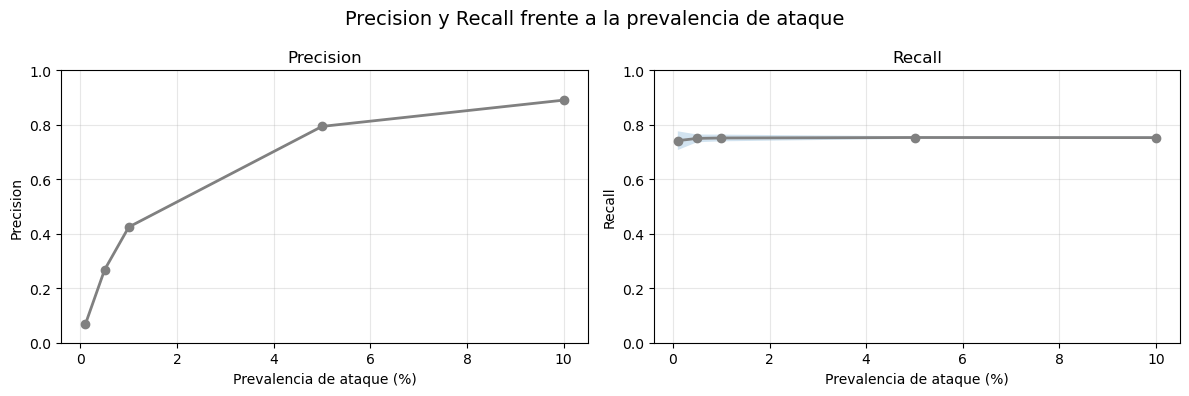

In [15]:
plot_summary = (
    prevalence_results
    .groupby("Attack prevalence")
    .agg({
        "Precision": ["mean", "std"],
        "Recall": ["mean", "std"],
        "FPR": ["mean", "std"],
        "MCC": ["mean", "std"],
    })
    .sort_index()
)

prevalence_values = plot_summary.index.to_numpy() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

metrics_to_plot = ["Precision", "Recall"]

for ax, metric in zip(axes, metrics_to_plot):
    mean_values = plot_summary[(metric, "mean")].to_numpy()
    std_values = plot_summary[(metric, "std")].to_numpy()

    ax.plot(prevalence_values, mean_values, marker="o", linewidth=2, color="gray")
    ax.fill_between(
        prevalence_values,
        mean_values - std_values,
        mean_values + std_values,
        alpha=0.2,
    )

    ax.set_title(metric)
    ax.set_xlabel("Prevalencia de ataque (%)")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

fig.suptitle("Precision y Recall frente a la prevalencia de ataque", fontsize=14)
fig.tight_layout()
plt.show()

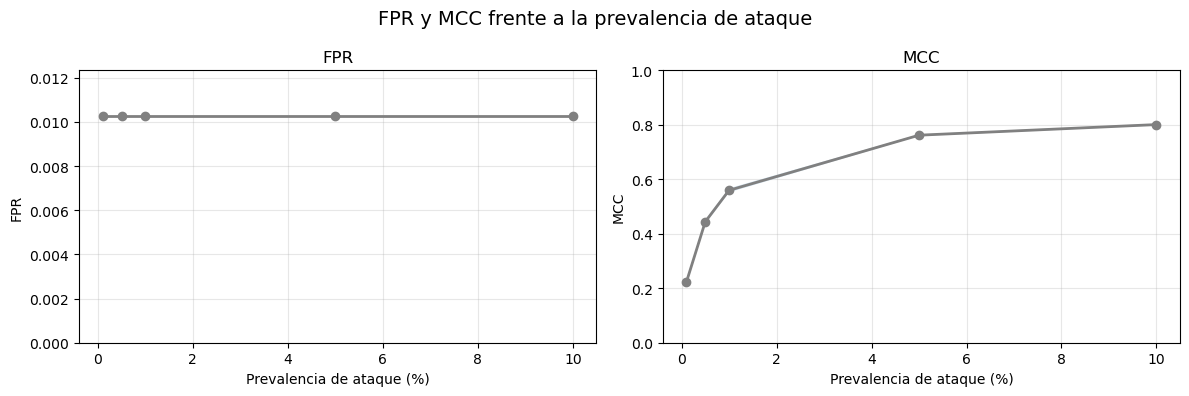

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

metrics_to_plot = ["FPR", "MCC"]

for ax, metric in zip(axes, metrics_to_plot):
    mean_values = plot_summary[(metric, "mean")].to_numpy()
    std_values = plot_summary[(metric, "std")].to_numpy()

    ax.plot(prevalence_values, mean_values, marker="o", linewidth=2, color="gray")
    ax.fill_between(
        prevalence_values,
        mean_values - std_values,
        mean_values + std_values,
        alpha=0.2,
    )

    ax.set_title(metric)
    ax.set_xlabel("Prevalencia de ataque (%)")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)

    if metric == "FPR":
        ax.set_ylim(0, max((mean_values + std_values).max() * 1.2, 0.01))
    else:
        ax.set_ylim(0, 1)

fig.suptitle("FPR y MCC frente a la prevalencia de ataque", fontsize=14)
fig.tight_layout()
plt.show()

Los resultados muestran que las métricas intrínsecas del detector, como el **recall** y la **False Positive Rate (FPR)**, permanecen prácticamente constantes para todas las prevalencias de ataque analizadas. Este comportamiento era esperable, ya que el modelo y los thresholds empleados no se modifican durante la evaluación, variando únicamente la proporción relativa entre tráfico benigno y malicioso.

En cambio, métricas dependientes de la distribución de clases, como la **precisión** y el **MCC**, experimentan un descenso progresivo conforme disminuye la prevalencia de ataques. Este comportamiento pone de manifiesto que, en escenarios donde el tráfico malicioso representa una fracción muy reducida del tráfico total, incluso una tasa de falsas alarmas relativamente baja puede generar un número considerable de falsos positivos, reduciendo la confianza que puede depositarse en cada alerta emitida por el sistema.

No obstante, resulta importante destacar que este comportamiento no responde a una degradación del detector, sino a un cambio en el contexto de evaluación. De hecho, la estrategia propuesta mantiene inalterada su capacidad de detección y su tasa de falsas alarmas independientemente del escenario considerado, lo que evidencia un comportamiento estable frente a variaciones en la prevalencia de ataque.

En conjunto, estos resultados muestran que la estrategia completamente no supervisada desarrollada en este trabajo mantiene un funcionamiento consistente bajo distintos escenarios operativos, permitiendo caracterizar de forma realista el compromiso existente entre capacidad de detección y falsas alarmas cuando el detector se despliega en entornos IoT donde el tráfico malicioso constituye únicamente una pequeña fracción de las comunicaciones.

### 5.2 Análisis de la robustez de una estrategia de recalibración supervisada del threshold

En el apartado anterior se ha evaluado la estrategia propuesta utilizando los thresholds seleccionados durante el stage 2, obtenidos exclusivamente a partir de tráfico benigno. Sin embargo, el análisis realizado en el apartado 4 puso de manifiesto que una recalibración supervisada del threshold permite mejorar considerablemente el rendimiento cuando se evalúa sobre el mismo escenario empleado para su ajuste.

No obstante, esta mejora no garantiza que el detector mantenga dicho comportamiento cuando cambian las condiciones de operación. En particular, en entornos reales la prevalencia de tráfico malicioso puede diferir significativamente de la utilizada durante la calibración del threshold, modificando el equilibrio entre capacidad de detección y tasa de falsas alarmas.

Con el objetivo de analizar esta situación, en este apartado se repite el estudio de sensibilidad frente a la prevalencia de ataque utilizando los thresholds calibrados mediante la maximización del coeficiente de correlación de Matthews (MCC). El propósito de este análisis no es obtener una nueva propuesta de detección, sino estudiar la robustez de una estrategia basada en recalibraciones supervisadas del threshold frente a cambios en el escenario operativo.

In [25]:
OPTIMAL_THRESHOLDS = threshold_analysis_df.set_index("device")["optimal_threshold"].to_dict()

optimal_results_df = results_df.copy()
optimal_results_df["y_pred"] = optimal_results_df.apply(
    lambda row: int(row["reconstruction_error"] > OPTIMAL_THRESHOLDS[row["device"]]), axis=1
)

optimal_benign_df = optimal_results_df[optimal_results_df["y_true"] == 0].copy()
optimal_attack_df = optimal_results_df[optimal_results_df["y_true"] == 1].copy()

In [26]:
rng = np.random.default_rng(RANDOM_STATE)

all_results = []
n_benign = len(optimal_benign_df)
for prevalence in ATTACK_PREVALENCES:

    n_attack = int(
        prevalence / (1 - prevalence) * n_benign
    )

    for repeat in range(N_REPEATS):

        sampled_attack = optimal_attack_df.sample(
            n=n_attack,
            replace=False,
            random_state=rng.integers(0, 1_000_000),
        )

        evaluation_df = pd.concat(
            [optimal_benign_df, sampled_attack],
            ignore_index=True,
        )

        metrics = compute_metrics(evaluation_df)

        metrics["Attack prevalence"] = prevalence
        metrics["Repeat"] = repeat

        all_results.append(metrics)

prevalence_results = pd.DataFrame(all_results)

In [27]:
summary = (
    prevalence_results
    .groupby("Attack prevalence")
    .agg({
        "Precision": ["mean", "std"],
        "Recall": ["mean", "std"],
        "FPR": ["mean", "std"],
        "MCC": ["mean", "std"],
    })
)

summary = summary.round(4)

display(summary)

Precision       Recall             FPR          MCC        
                       mean  std    mean     std    mean  std    mean     std
Attack prevalence                                                            
0.001                0.0307  0.0  1.0000  0.0000  0.0315  0.0  0.1724  0.0000
0.005                0.1373  0.0  0.9999  0.0003  0.0315  0.0  0.3646  0.0001
0.010                0.2426  0.0  0.9999  0.0002  0.0315  0.0  0.4847  0.0001
0.050                0.6253  0.0  1.0000  0.0001  0.0315  0.0  0.7782  0.0000
0.100                0.7789  0.0  1.0000  0.0000  0.0315  0.0  0.8685  0.0000

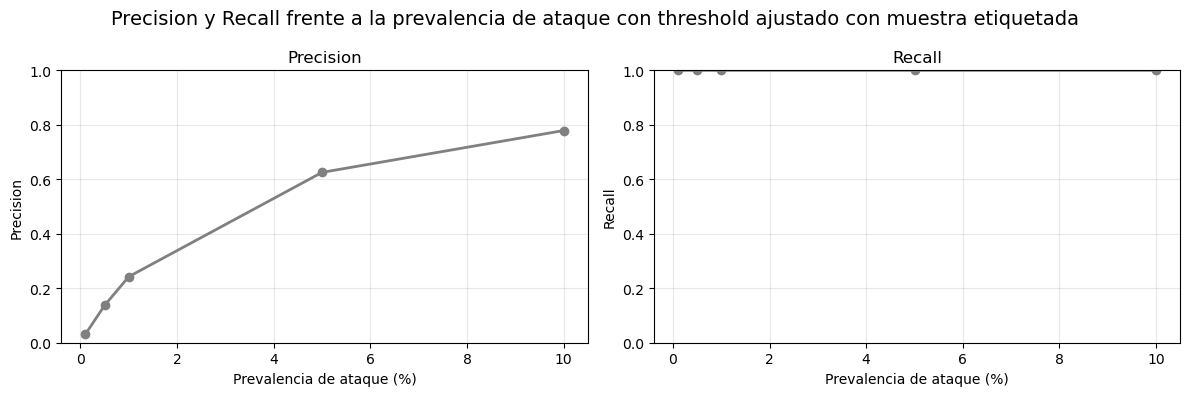

In [32]:
plot_summary = (
    prevalence_results
    .groupby("Attack prevalence")
    .agg({
        "Precision": ["mean", "std"],
        "Recall": ["mean", "std"],
        "FPR": ["mean", "std"],
        "MCC": ["mean", "std"],
    })
    .sort_index()
)

prevalence_values = plot_summary.index.to_numpy() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

metrics_to_plot = ["Precision", "Recall"]

for ax, metric in zip(axes, metrics_to_plot):
    mean_values = plot_summary[(metric, "mean")].to_numpy()
    std_values = plot_summary[(metric, "std")].to_numpy()

    ax.plot(prevalence_values, mean_values, marker="o", linewidth=2, color="gray")
    ax.fill_between(
        prevalence_values,
        mean_values - std_values,
        mean_values + std_values,
        alpha=0.2,
    )

    ax.set_title(metric)
    ax.set_xlabel("Prevalencia de ataque (%)")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

fig.suptitle("Precision y Recall frente a la prevalencia de ataque con threshold ajustado con muestra etiquetada", fontsize=14)
fig.tight_layout()
plt.show()

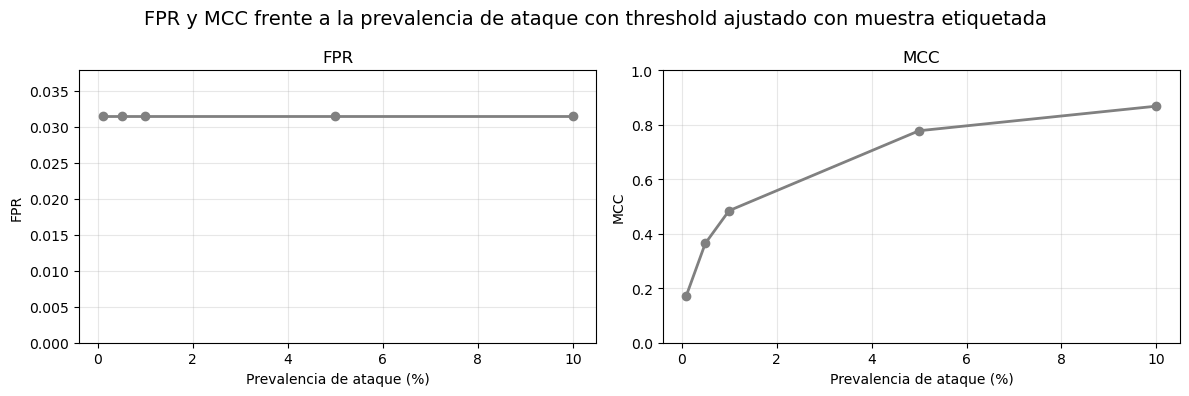

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

metrics_to_plot = ["FPR", "MCC"]

for ax, metric in zip(axes, metrics_to_plot):
    mean_values = plot_summary[(metric, "mean")].to_numpy()
    std_values = plot_summary[(metric, "std")].to_numpy()

    ax.plot(prevalence_values, mean_values, marker="o", linewidth=2, color="gray")
    ax.fill_between(
        prevalence_values,
        mean_values - std_values,
        mean_values + std_values,
        alpha=0.2,
    )

    ax.set_title(metric)
    ax.set_xlabel("Prevalencia de ataque (%)")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)

    if metric == "FPR":
        ax.set_ylim(0, max((mean_values + std_values).max() * 1.2, 0.01))
    else:
        ax.set_ylim(0, 1)

fig.suptitle("FPR y MCC frente a la prevalencia de ataque con threshold ajustado con muestra etiquetada", fontsize=14)
fig.tight_layout()
plt.show()

Los resultados muestran que la recalibración supervisada del threshold mantiene un **recall prácticamente del 100 %** para todas las prevalencias de ataque consideradas, lo que confirma que los nuevos thresholds permiten recuperar prácticamente la totalidad de las muestras maliciosas sin necesidad de reentrenar los modelos.

Sin embargo, esta mejora viene acompañada de un incremento permanente de la **False Positive Rate (FPR)**, que pasa aproximadamente del **1 %** al **3.15 %**. Aunque este aumento puede parecer reducido en términos absolutos, su impacto resulta especialmente significativo cuando la prevalencia de ataques disminuye. En estos escenarios, el elevado número de muestras benignas provoca que un incremento moderado del FPR se traduzca en un aumento considerable del número de falsas alarmas, reduciendo de forma notable la precisión del detector.

Este comportamiento pone de manifiesto una limitación importante de las estrategias basadas en recalibración supervisada del threshold. El valor seleccionado resulta adecuado para el escenario utilizado durante la calibración, pero no necesariamente mantiene el mismo equilibrio entre detecciones y falsas alarmas cuando cambian las condiciones de operación. En consecuencia, conservar un rendimiento óptimo requeriría realizar nuevas recalibraciones adaptadas a cada entorno de despliegue, lo que implica disponer de muestras de ataque etiquetadas representativas y asumir un coste de mantenimiento continuo del sistema.

En conjunto, estos resultados evidencian que una recalibración supervisada del threshold constituye una alternativa viable para mejorar el rendimiento en escenarios concretos, pero también muestran que dicha estrategia pierde parte de su atractivo en entornos dinámicos, donde la prevalencia y las características del tráfico pueden variar con el tiempo. Desde esta perspectiva, la estrategia completamente no supervisada propuesta en este trabajo presenta la ventaja de mantener un comportamiento más estable y fácilmente desplegable al no depender de procesos periódicos de recalibración.

## 6. Escalabilidad de Autoencoder por dispositivo

## 7. Conclusiones específicas de Autoencoder por dispositivo